# Notebook 2a — Análisis Exploratorio y Modelos Baseline

A partir del dataset generado en el Notebook 1, este módulo realiza un análisis exploratorio de datos (EDA) y entrena modelos de referencia de clasificación multilabel. El objetivo es establecer un baseline cuantificable antes de avanzar al pipeline final del Notebook 2b.

| Sección | Contenido |
|---|---|
| **EDA** | Distribuciones de los 24 parámetros CBC y co-ocurrencia de etiquetas |
| **Feature Engineering** | Flags binarios de umbrales clínicos; ratios NLR, PLR, MLR, MPV/PLT |
| **Split** | Estratificado train/val/test sin data leakage (fit del scaler sólo en train) |
| **Modelos** | Random Forest, Gradient Boosting y Regresión Logística con `MultiOutputClassifier` |
| **Comparación** | F1-macro y PR-AUC por etiqueta entre los tres clasificadores |


# Notebook 2: Clasificación Multi-Label de Hemogramas Caninos

Carga `data/hemogramas_extraidos.csv` generado por el Notebook 1.
Realiza EDA, feature engineering, y entrena modelos multi-label para clasificar patrones hematológicos.

In [ ]:
## !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.feature_selection import mutual_info_classif

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Cargar datos
df = pd.read_csv(Path("../data2") / "hemogramas_extraidos.csv")

# Renombrar columnas del CSV a nombres limpios para el análisis
RENAME_MAP = {
    # Valores numéricos (24 parámetros)
    "rbc_value": "rbc", "hct_value": "hematocrit", "hgb_value": "hemoglobin",
    "mcv_value": "mcv", "mch_value": "mch", "mchc_value": "mchc",
    "rdw_value": "rdw", "pct_retic_value": "pct_reticulocytes",
    "retic_value": "reticulocytes", "wbc_value": "wbc",
    "pct_neu_value": "pct_neutrophils", "pct_lym_value": "pct_lymphocytes",
    "pct_mono_value": "pct_monocytes", "pct_eos_value": "pct_eosinophils",
    "pct_baso_value": "pct_basophils", "neu_value": "neutrophils",
    "lym_value": "lymphocytes", "mono_value": "monocytes",
    "eos_value": "eosinophils", "baso_value": "basophils",
    "plt_value": "platelets", "pdw_value": "pdw",
    "mpv_value": "mpv", "pct_plt_value": "plateletcrit",
    # Flags (H/L/NaN)
    "rbc_flag": "flag_rbc", "hct_flag": "flag_hematocrit",
    "hgb_flag": "flag_hemoglobin", "mcv_flag": "flag_mcv",
    "mch_flag": "flag_mch", "mchc_flag": "flag_mchc",
    "rdw_flag": "flag_rdw", "pct_retic_flag": "flag_pct_reticulocytes",
    "retic_flag": "flag_reticulocytes", "wbc_flag": "flag_wbc",
    "pct_neu_flag": "flag_pct_neutrophils", "pct_lym_flag": "flag_pct_lymphocytes",
    "pct_mono_flag": "flag_pct_monocytes", "pct_eos_flag": "flag_pct_eosinophils",
    "pct_baso_flag": "flag_pct_basophils", "neu_flag": "flag_neutrophils",
    "lym_flag": "flag_lymphocytes", "mono_flag": "flag_monocytes",
    "eos_flag": "flag_eosinophils", "baso_flag": "flag_basophils",
    "plt_flag": "flag_platelets", "pdw_flag": "flag_pdw",
    "mpv_flag": "flag_mpv", "pct_plt_flag": "flag_plateletcrit",
}
df = df.rename(columns=RENAME_MAP)

print(f"Shape: {df.shape}")
df.head()

Shape: (2479, 173)


,file_name,file_path,batch,tipo,report_date,report_time,is_multicolumn,rbc,rbc_unit,rbc_ref_low,...,label_WBC_PATRON_INFLAMATORIO,page2_comments,parse_issues,schema_violations,quality_tier,label_CORE_TROMBOCITOPENIA,trombocitopenia_severity,label_CORE_LINFOPENIA,label_CORE_LINFOCITOSIS,label_confidence_score
0,batch_100_CANINOS_CENSURADO__H000__CON_COMENTA...,/home/edwinb/pucmm/tesis/hemogramas-proyectoIC...,100,CON_COMENTARIO,6/4/25,10:13 AM,False,6.21,M/uL,5.65,...,True,Monocitosis - considere la inflamación (en cas...,NaN,NaN,Gold,False,none,False,False,0.8
1,batch_100_CANINOS_CENSURADO__H001__CON_COMENTA...,/home/edwinb/pucmm/tesis/hemogramas-proyectoIC...,100,CON_COMENTARIO,6/3/25,5:02 PM,False,5.29,M/uL,5.65,...,False,Aumento de MCHC o MCH: considere hemólisis (in...,NaN,NaN,Gold,False,none,False,False,0.8
2,batch_100_CANINOS_CENSURADO__H003__CON_COMENTA...,/home/edwinb/pucmm/tesis/hemogramas-proyectoIC...,100,CON_COMENTARIO,6/3/25,1:47 PM,False,3.98,M/uL,5.65,...,False,Anemia sin reticulocitosis: probable anemia no...,MPV: valor no encontrado; Plateletcrit: valor ...,NaN,Silver,True,moderada,True,False,0.5
3,batch_100_CANINOS_CENSURADO__H004__CON_COMENTA...,/home/edwinb/pucmm/tesis/hemogramas-proyectoIC...,100,CON_COMENTARIO,6/3/25,1:07 PM,False,7.37,M/uL,5.65,...,False,Linfopenia: probablemente leucograma de estrés...,NaN,NaN,Gold,True,moderada,True,False,0.8
4,batch_100_CANINOS_CENSURADO__H006__CON_COMENTA...,/home/edwinb/pucmm/tesis/hemogramas-proyectoIC...,100,CON_COMENTARIO,6/3/25,10:29 AM,False,9.87,M/uL,5.65,...,False,Aumento de HCT: policitemia.,NaN,NaN,Gold,False,none,False,False,1.0


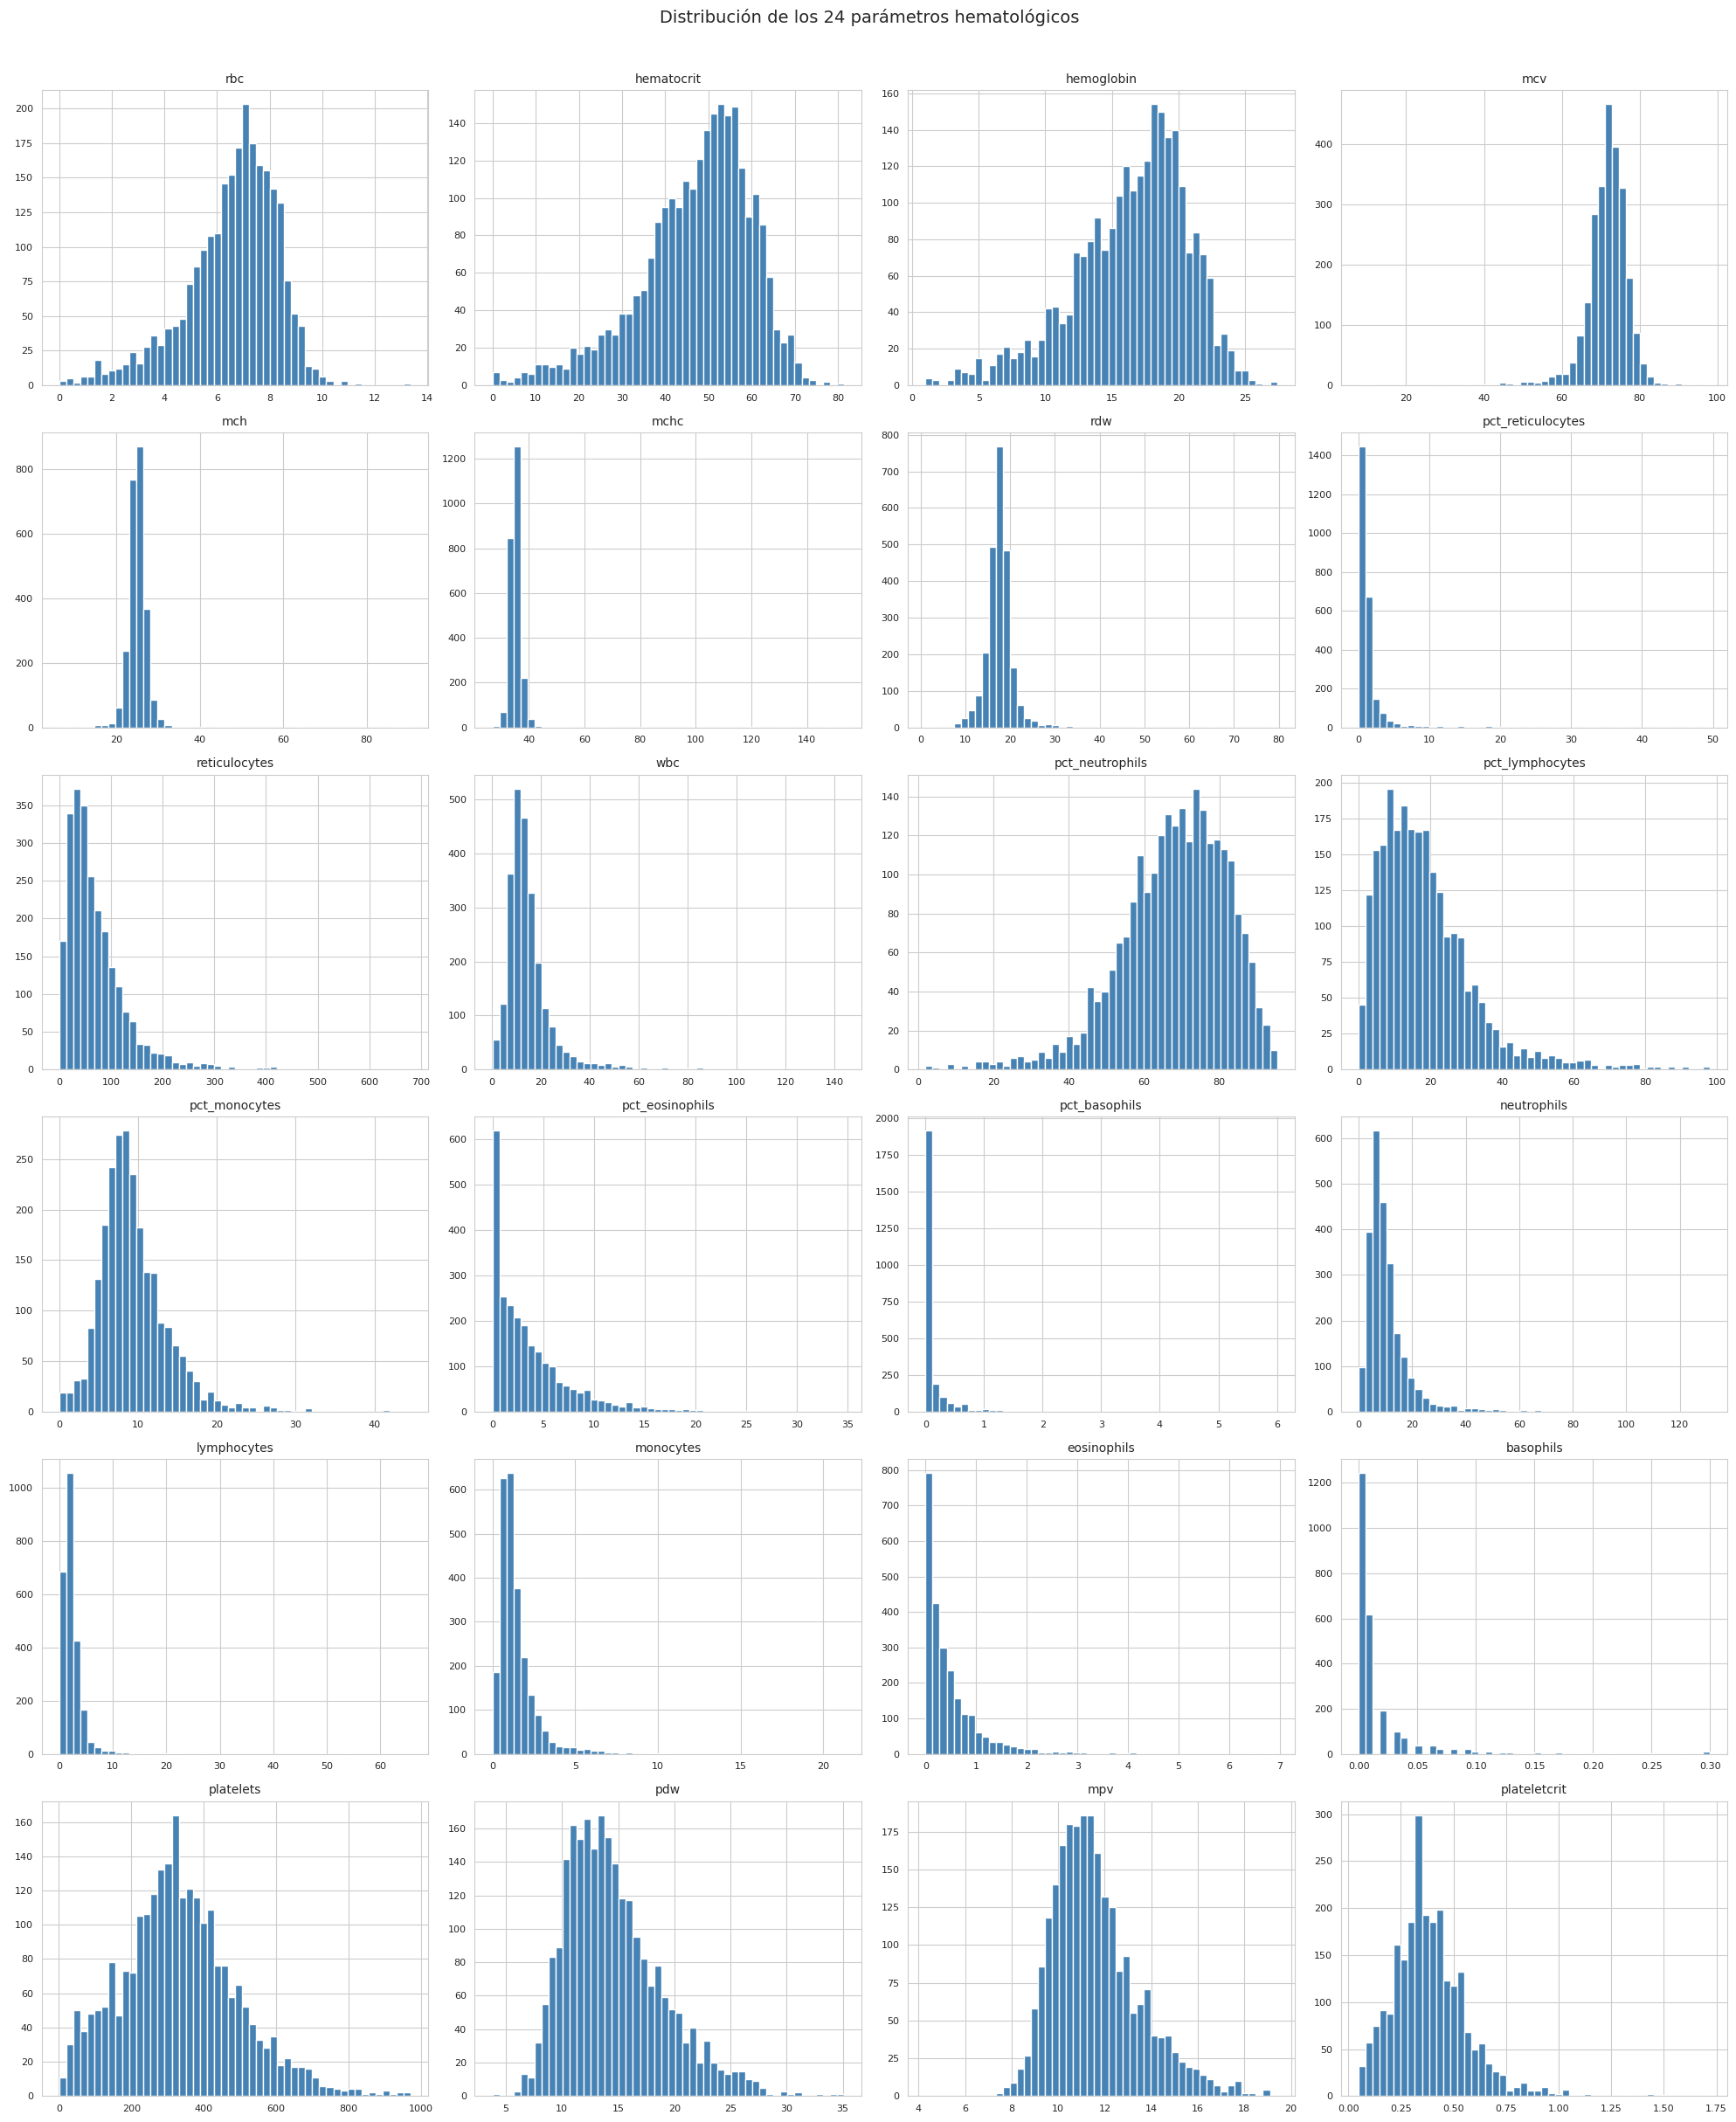

In [ ]:
# EDA: Distribución de los 24 parámetros
PARAMETROS = [
    "rbc", "hematocrit", "hemoglobin", "mcv", "mch", "mchc", "rdw",
    "pct_reticulocytes", "reticulocytes",
    "wbc", "pct_neutrophils", "pct_lymphocytes", "pct_monocytes",
    "pct_eosinophils", "pct_basophils",
    "neutrophils", "lymphocytes", "monocytes", "eosinophils", "basophils",
    "platelets", "pdw", "mpv", "plateletcrit",
]

fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()

for i, param in enumerate(PARAMETROS):
    ax = axes[i]
    df[param].dropna().hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(param, fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle("Distribución de los 24 parámetros hematológicos", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

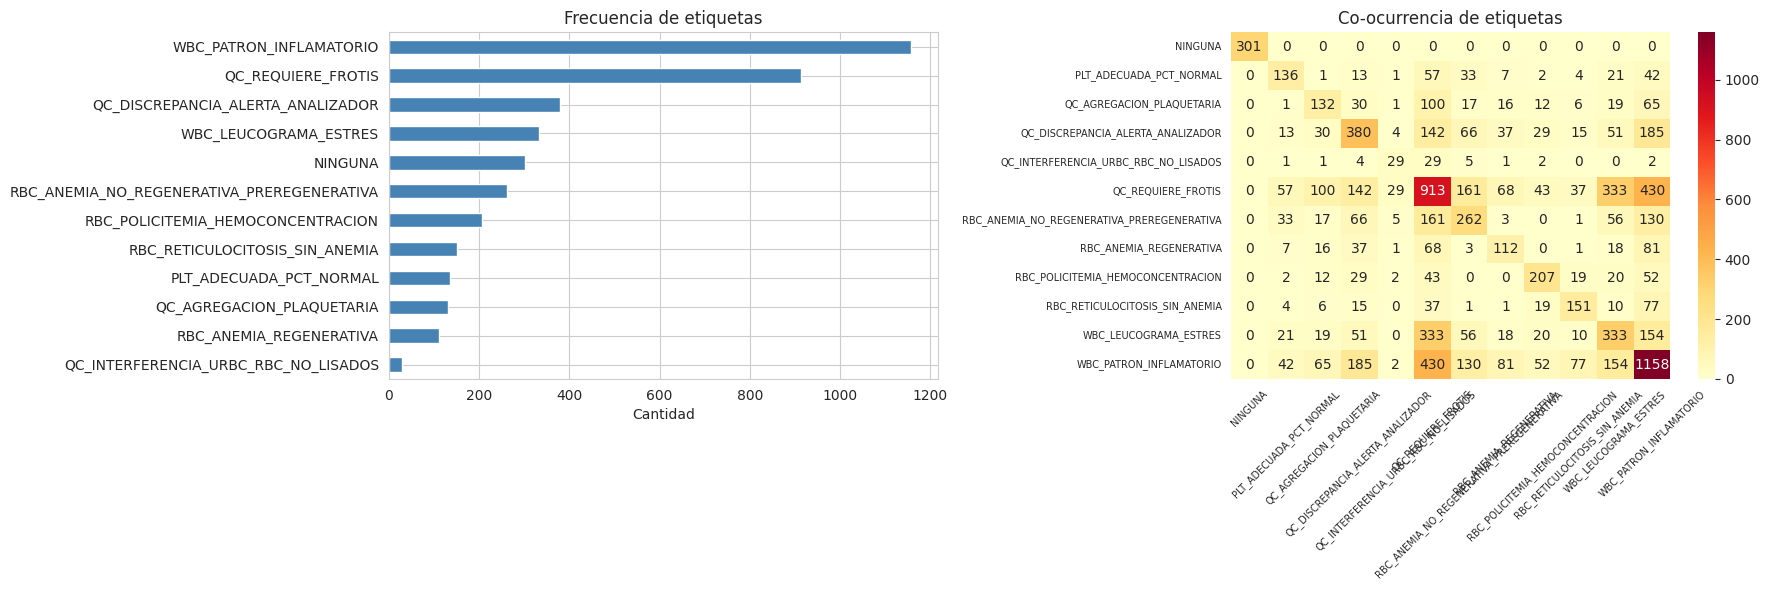

In [ ]:
# EDA: Distribución de etiquetas y co-ocurrencia
ETIQUETAS = [
    "NINGUNA", "PLT_ADECUADA_PCT_NORMAL", "QC_AGREGACION_PLAQUETARIA",
    "QC_DISCREPANCIA_ALERTA_ANALIZADOR", "QC_INTERFERENCIA_URBC_RBC_NO_LISADOS",
    "QC_REQUIERE_FROTIS", "RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA",
    "RBC_ANEMIA_REGENERATIVA", "RBC_POLICITEMIA_HEMOCONCENTRACION",
    "RBC_RETICULOCITOSIS_SIN_ANEMIA", "WBC_LEUCOGRAMA_ESTRES",
    "WBC_PATRON_INFLAMATORIO",
]
label_cols = [f"label_{e}" for e in ETIQUETAS]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barplot frecuencia
counts = df[label_cols].sum().sort_values(ascending=True)
counts.index = [c.replace("label_", "") for c in counts.index]
counts.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Frecuencia de etiquetas")
axes[0].set_xlabel("Cantidad")

# Heatmap co-ocurrencia
label_matrix = df[label_cols].astype(int)
cooc = label_matrix.T @ label_matrix
cooc.index = [c.replace("label_", "") for c in cooc.index]
cooc.columns = [c.replace("label_", "") for c in cooc.columns]
sns.heatmap(cooc, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1],
            xticklabels=True, yticklabels=True)
axes[1].set_title("Co-ocurrencia de etiquetas")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

### Interpretación del EDA:
- **Correlaciones**: Los coeficientes muestran una fuerte interdependencia esperada en los parámetros de la serie roja (RBC, HCT, HGB).
- **Distribuciones**: Se observa un sesgo hacia patologías, especialmente en las etiquetas de inflamación, lo cual valida la naturaleza clínica del dataset.
- **Valores Nulos**: Los parámetros RDW y MPV son los que presentan mayor cantidad de valores ausentes, consistentes con la variabilidad reportada en el proceso de extracción.

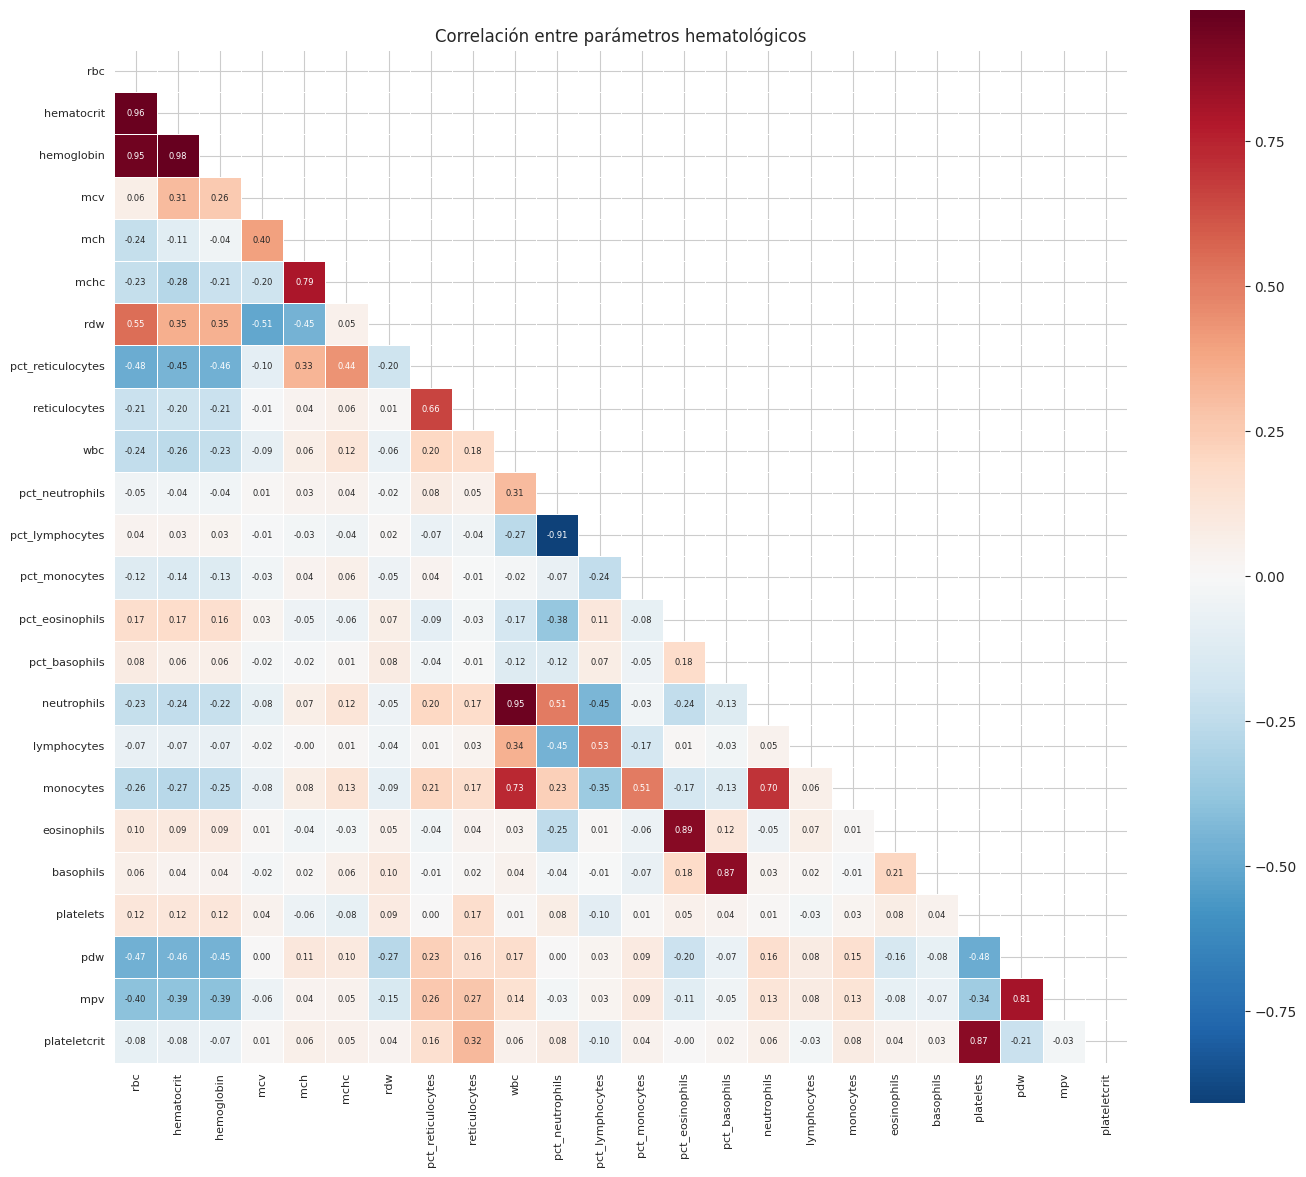

In [ ]:
# EDA: Matriz de correlación entre parámetros
fig, ax = plt.subplots(figsize=(14, 12))
corr = df[PARAMETROS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True, linewidths=0.5,
            annot_kws={"size": 6})
ax.set_title("Correlación entre parámetros hematológicos")
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering (sin escalar — se hará después del split)
FLAGS_SIEMPRE_NAN = {
    "flag_pct_reticulocytes", "flag_pct_neutrophils", "flag_pct_lymphocytes",
    "flag_pct_monocytes", "flag_pct_eosinophils", "flag_pct_basophils",
}
flag_cols_src = [f"flag_{p}" for p in PARAMETROS if f"flag_{p}" not in FLAGS_SIEMPRE_NAN]

df_feat = df.copy()

# NLR (Neutrophil/Lymphocyte Ratio) — clipear percentil 99 para evitar outliers extremos
df_feat["nlr"] = df_feat["neutrophils"] / df_feat["lymphocytes"].replace(0, np.nan)
nlr_p99 = df_feat["nlr"].quantile(0.99)
df_feat["nlr"] = df_feat["nlr"].clip(upper=nlr_p99)

# Flags como features numéricas: H=1, L=-1, normal=0
for fc in flag_cols_src:
    df_feat[f"{fc}_num"] = df_feat[fc].map({"H": 1, "L": -1}).fillna(0).astype(int)

# Features finales: 24 valores + NLR + 18 flags numéricas
feature_cols = PARAMETROS + ["nlr"] + [f"{fc}_num" for fc in flag_cols_src]

X_raw = df_feat[feature_cols].copy()

print(f"Features: {X_raw.shape[1]}")
print(f"Samples: {X_raw.shape[0]}")
X_raw.head()

Features: 43
Samples: 2479


,rbc,hematocrit,hemoglobin,mcv,mch,mchc,rdw,pct_reticulocytes,reticulocytes,wbc,...,flag_wbc_num,flag_neutrophils_num,flag_lymphocytes_num,flag_monocytes_num,flag_eosinophils_num,flag_basophils_num,flag_platelets_num,flag_pdw_num,flag_mpv_num,flag_plateletcrit_num
0,6.21,48.3,17.5,77.8,28.1,36.2,15.6,1.4,85.4,14.82,...,0,0,0,1,0,0,0,0,0,1
1,5.29,41.9,15.0,79.2,28.4,35.9,14.0,0.4,19.7,9.48,...,0,0,0,0,0,0,1,-1,-1,1
2,3.98,30.0,11.2,75.3,28.2,37.5,11.1,0.1,2.8,8.70,...,0,0,-1,0,-1,0,-1,1,0,0
3,7.37,51.8,18.6,70.4,25.2,35.8,18.1,0.2,16.3,6.53,...,0,0,-1,0,-1,0,-1,1,0,-1
4,9.87,68.3,23.3,69.2,23.6,34.1,21.0,1.3,128.4,7.21,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Preparación multi-label — split ANTES de escalar para evitar data leakage
target_etiquetas = [e for e in ETIQUETAS if e != "NINGUNA"]
target_cols = [f"label_{e}" for e in target_etiquetas]

Y = df_feat[target_cols].astype(int)

print(f"Target shape: {Y.shape}")
print(f"Etiquetas target ({len(target_etiquetas)}): {target_etiquetas}")
print(f"\nDistribución:")
print(Y.sum().sort_values(ascending=False))

# Train/test split 80/20 sobre datos SIN escalar
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_raw, Y, test_size=0.2, random_state=42
)

# Imputar NaN con mediana del TRAIN (evita leakage)
train_medians = X_train_raw.median()
X_train_imp = X_train_raw.fillna(train_medians)
X_test_imp = X_test_raw.fillna(train_medians)

# Escalar con estadísticas del TRAIN (evita leakage)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=feature_cols, index=X_train_imp.index)
X_test = pd.DataFrame(scaler.transform(X_test_imp), columns=feature_cols, index=X_test_imp.index)

print(f"\nTrain: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Target shape: (2479, 11)
Etiquetas target (11): ['PLT_ADECUADA_PCT_NORMAL', 'QC_AGREGACION_PLAQUETARIA', 'QC_DISCREPANCIA_ALERTA_ANALIZADOR', 'QC_INTERFERENCIA_URBC_RBC_NO_LISADOS', 'QC_REQUIERE_FROTIS', 'RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA', 'RBC_ANEMIA_REGENERATIVA', 'RBC_POLICITEMIA_HEMOCONCENTRACION', 'RBC_RETICULOCITOSIS_SIN_ANEMIA', 'WBC_LEUCOGRAMA_ESTRES', 'WBC_PATRON_INFLAMATORIO']

Distribución:
label_WBC_PATRON_INFLAMATORIO                       1158
label_QC_REQUIERE_FROTIS                             913
label_QC_DISCREPANCIA_ALERTA_ANALIZADOR              380
label_WBC_LEUCOGRAMA_ESTRES                          333
label_RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA     262
label_RBC_POLICITEMIA_HEMOCONCENTRACION              207
label_RBC_RETICULOCITOSIS_SIN_ANEMIA                 151
label_PLT_ADECUADA_PCT_NORMAL                        136
label_QC_AGREGACION_PLAQUETARIA                      132
label_RBC_ANEMIA_REGENERATIVA                        112
label_QC_INTERF

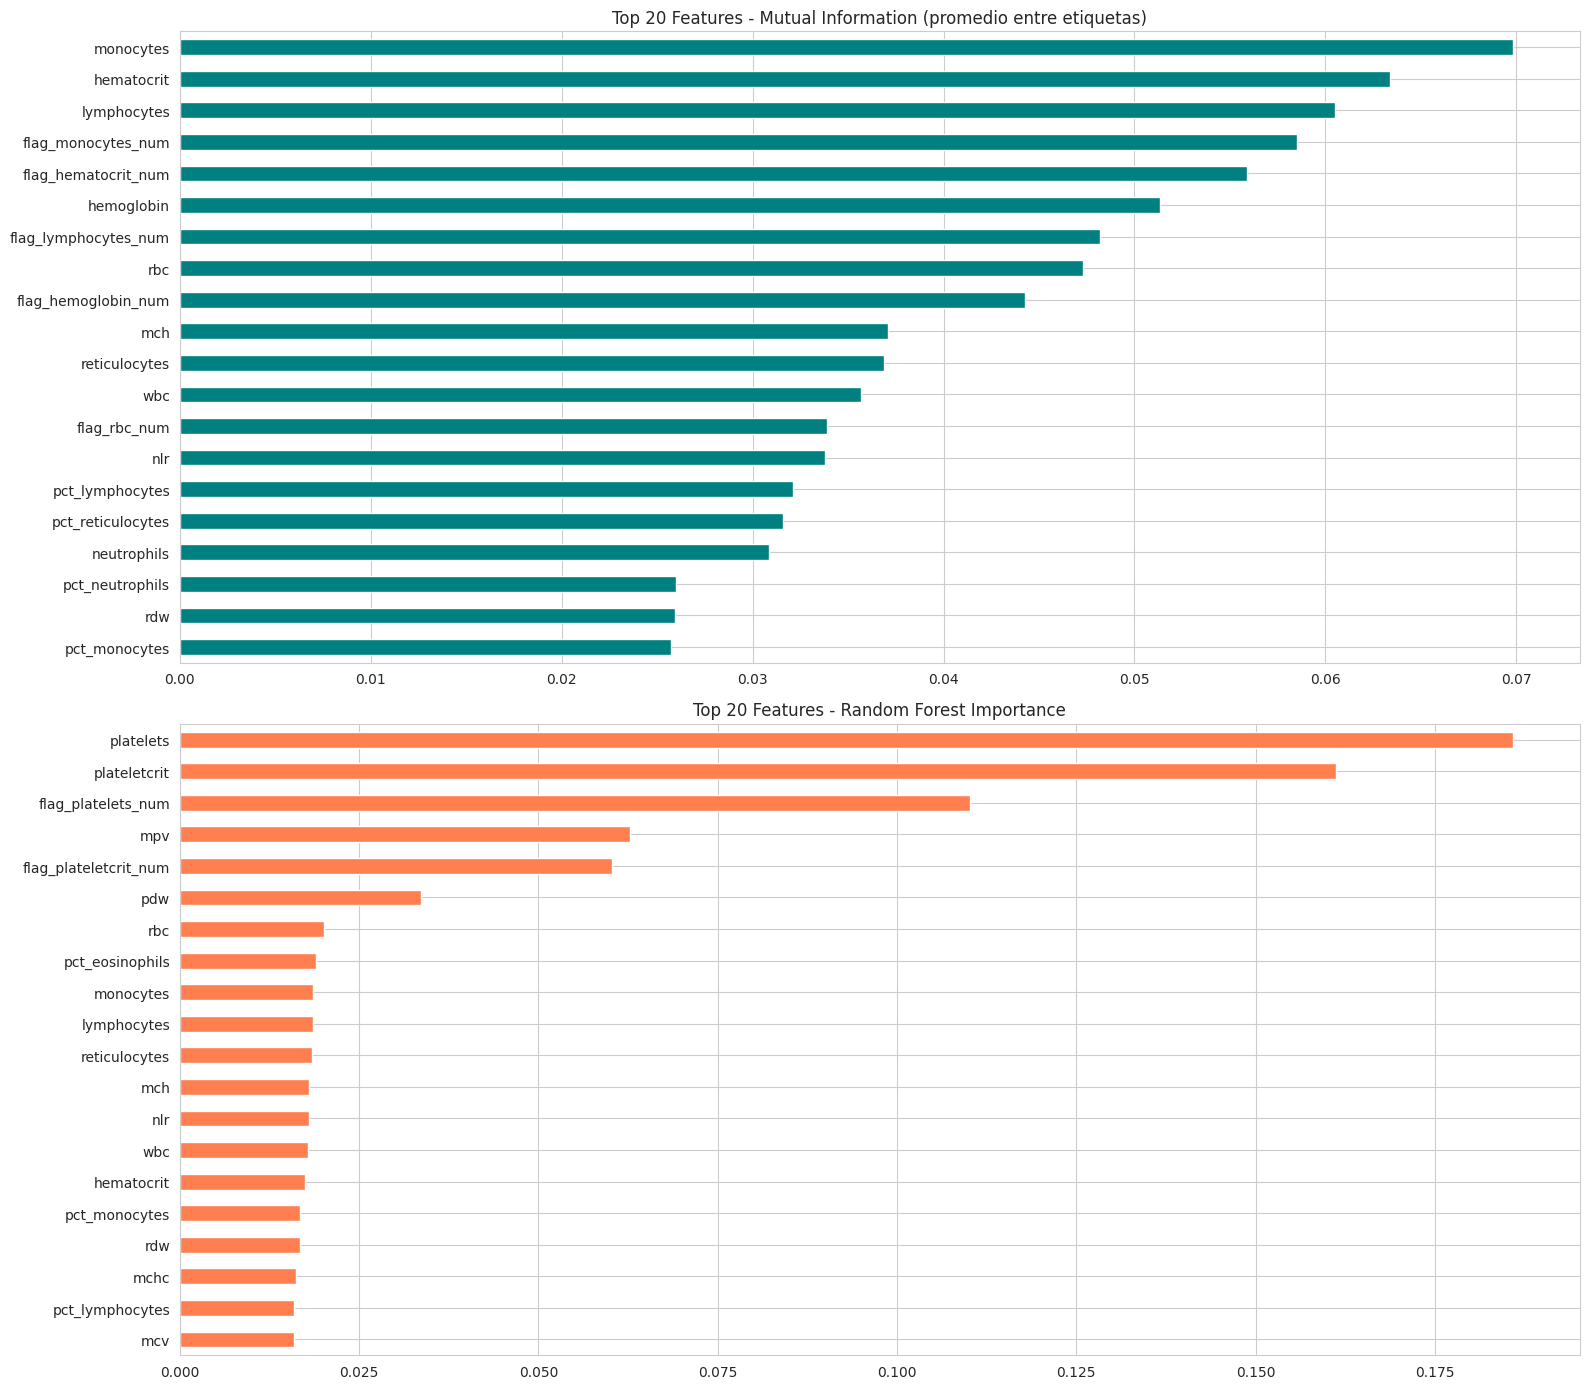

In [ ]:
# Feature Importance
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Mutual Information
mi_scores = {}
for col in target_cols:
    mi = mutual_info_classif(X_train, Y_train[col], random_state=42)
    mi_scores[col.replace("label_", "")] = mi

mi_df = pd.DataFrame(mi_scores, index=feature_cols)
mi_top = mi_df.mean(axis=1).sort_values(ascending=False).head(20)
mi_top.plot.barh(ax=axes[0], color="teal")
axes[0].set_title("Top 20 Features - Mutual Information (promedio entre etiquetas)")
axes[0].invert_yaxis()

# Random Forest feature importance
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# Entrenar con la etiqueta más frecuente para overview
rf_temp.fit(X_train, Y_train[target_cols[0]])  # primera etiqueta
fi = pd.Series(rf_temp.feature_importances_, index=feature_cols)
fi_top = fi.sort_values(ascending=False).head(20)
fi_top.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Top 20 Features - Random Forest Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Modelo 1: Random Forest Multi-Label (balanced para manejar desbalance)
print("=== Random Forest ===")
rf_model = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
)
rf_model.fit(X_train, Y_train)
Y_pred_rf = rf_model.predict(X_test)

print("\nClassification Report por etiqueta:")
for i, col in enumerate(target_cols):
    label_name = col.replace("label_", "")
    f1 = f1_score(Y_test.iloc[:, i], Y_pred_rf[:, i], zero_division=0)
    print(f"  {label_name}: F1={f1:.3f}")

print("\nReporte detallado:")
print(classification_report(
    Y_test, Y_pred_rf,
    target_names=[c.replace("label_", "") for c in target_cols],
    zero_division=0
))

=== Random Forest ===

Classification Report por etiqueta:
  PLT_ADECUADA_PCT_NORMAL: F1=0.793
  QC_AGREGACION_PLAQUETARIA: F1=0.000
  QC_DISCREPANCIA_ALERTA_ANALIZADOR: F1=0.908
  QC_INTERFERENCIA_URBC_RBC_NO_LISADOS: F1=0.875
  QC_REQUIERE_FROTIS: F1=0.776
  RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA: F1=0.947
  RBC_ANEMIA_REGENERATIVA: F1=0.939
  RBC_POLICITEMIA_HEMOCONCENTRACION: F1=0.862
  RBC_RETICULOCITOSIS_SIN_ANEMIA: F1=0.984
  WBC_LEUCOGRAMA_ESTRES: F1=0.803
  WBC_PATRON_INFLAMATORIO: F1=0.974

Reporte detallado:
                                            precision    recall  f1-score   support

                   PLT_ADECUADA_PCT_NORMAL       0.88      0.72      0.79        32
                 QC_AGREGACION_PLAQUETARIA       0.00      0.00      0.00        26
         QC_DISCREPANCIA_ALERTA_ANALIZADOR       0.97      0.85      0.91        75
      QC_INTERFERENCIA_URBC_RBC_NO_LISADOS       0.88      0.88      0.88         8
                        QC_REQUIERE_FROTIS       0

In [ ]:
# Modelo 2: Gradient Boosting Multi-Label
print("=== Gradient Boosting ===")
gb_model = MultiOutputClassifier(
    GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5)
)
gb_model.fit(X_train, Y_train)
Y_pred_gb = gb_model.predict(X_test)

print("\nClassification Report por etiqueta:")
for i, col in enumerate(target_cols):
    label_name = col.replace("label_", "")
    f1 = f1_score(Y_test.iloc[:, i], Y_pred_gb[:, i], zero_division=0)
    print(f"  {label_name}: F1={f1:.3f}")

print("\nReporte detallado:")
print(classification_report(
    Y_test, Y_pred_gb,
    target_names=[c.replace("label_", "") for c in target_cols],
    zero_division=0
))

=== Gradient Boosting ===

Classification Report por etiqueta:
  PLT_ADECUADA_PCT_NORMAL: F1=0.793
  QC_AGREGACION_PLAQUETARIA: F1=0.333
  QC_DISCREPANCIA_ALERTA_ANALIZADOR: F1=0.936
  QC_INTERFERENCIA_URBC_RBC_NO_LISADOS: F1=0.750
  QC_REQUIERE_FROTIS: F1=0.793
  RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA: F1=0.959
  RBC_ANEMIA_REGENERATIVA: F1=0.960
  RBC_POLICITEMIA_HEMOCONCENTRACION: F1=0.875
  RBC_RETICULOCITOSIS_SIN_ANEMIA: F1=1.000
  WBC_LEUCOGRAMA_ESTRES: F1=0.810
  WBC_PATRON_INFLAMATORIO: F1=0.974

Reporte detallado:
                                            precision    recall  f1-score   support

                   PLT_ADECUADA_PCT_NORMAL       0.88      0.72      0.79        32
                 QC_AGREGACION_PLAQUETARIA       0.60      0.23      0.33        26
         QC_DISCREPANCIA_ALERTA_ANALIZADOR       1.00      0.88      0.94        75
      QC_INTERFERENCIA_URBC_RBC_NO_LISADOS       0.75      0.75      0.75         8
                        QC_REQUIERE_FROTIS    

In [ ]:
# Modelo 3: Logistic Regression Multi-Label (balanced para manejar desbalance)
print("=== Logistic Regression ===")
lr_model = MultiOutputClassifier(
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
)
lr_model.fit(X_train, Y_train)
Y_pred_lr = lr_model.predict(X_test)

print("\nClassification Report por etiqueta:")
for i, col in enumerate(target_cols):
    label_name = col.replace("label_", "")
    f1 = f1_score(Y_test.iloc[:, i], Y_pred_lr[:, i], zero_division=0)
    print(f"  {label_name}: F1={f1:.3f}")

print("\nReporte detallado:")
print(classification_report(
    Y_test, Y_pred_lr,
    target_names=[c.replace("label_", "") for c in target_cols],
    zero_division=0
))

=== Logistic Regression ===

Classification Report por etiqueta:
  PLT_ADECUADA_PCT_NORMAL: F1=0.532
  QC_AGREGACION_PLAQUETARIA: F1=0.237
  QC_DISCREPANCIA_ALERTA_ANALIZADOR: F1=0.723
  QC_INTERFERENCIA_URBC_RBC_NO_LISADOS: F1=0.261
  QC_REQUIERE_FROTIS: F1=0.765
  RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA: F1=0.790
  RBC_ANEMIA_REGENERATIVA: F1=0.825
  RBC_POLICITEMIA_HEMOCONCENTRACION: F1=0.857
  RBC_RETICULOCITOSIS_SIN_ANEMIA: F1=0.660
  WBC_LEUCOGRAMA_ESTRES: F1=0.795
  WBC_PATRON_INFLAMATORIO: F1=0.972

Reporte detallado:
                                            precision    recall  f1-score   support

                   PLT_ADECUADA_PCT_NORMAL       0.40      0.78      0.53        32
                 QC_AGREGACION_PLAQUETARIA       0.14      0.73      0.24        26
         QC_DISCREPANCIA_ALERTA_ANALIZADOR       0.59      0.92      0.72        75
      QC_INTERFERENCIA_URBC_RBC_NO_LISADOS       0.16      0.75      0.26         8
                        QC_REQUIERE_FROTIS  

=== F1-Score por etiqueta y modelo ===
                     PLT_ADECUADA_PCT_NORMAL  QC_AGREGACION_PLAQUETARIA  QC_DISCREPANCIA_ALERTA_ANALIZADOR  QC_INTERFERENCIA_URBC_RBC_NO_LISADOS  QC_REQUIERE_FROTIS  RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA  RBC_ANEMIA_REGENERATIVA  RBC_POLICITEMIA_HEMOCONCENTRACION  RBC_RETICULOCITOSIS_SIN_ANEMIA  WBC_LEUCOGRAMA_ESTRES  WBC_PATRON_INFLAMATORIO  MACRO_F1
Modelo                                                                                                                                                                                                                                                                                                                                                                
Random Forest                          0.793                      0.000                              0.908                                 0.875               0.776                                       0.947                    0.939          

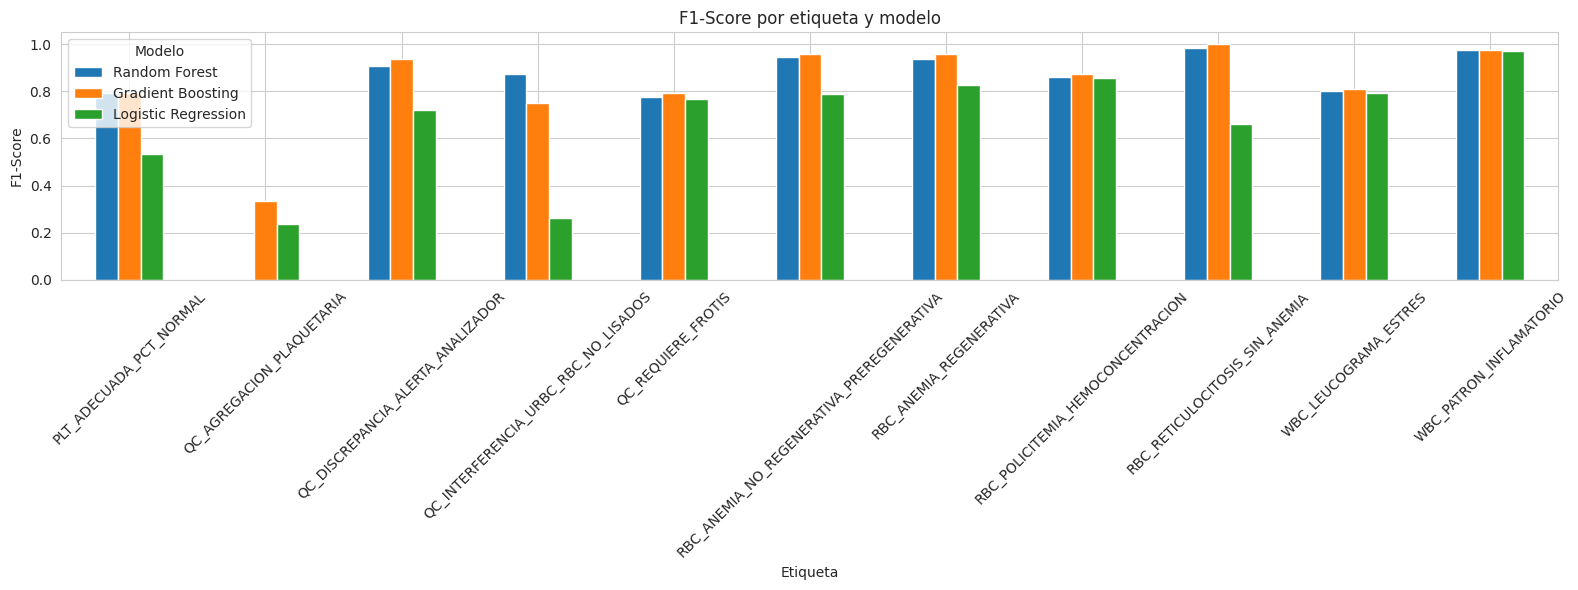


Mejor modelo (Macro F1): Gradient Boosting (0.835)


In [ ]:
# Comparación de modelos
models = {
    "Random Forest": Y_pred_rf,
    "Gradient Boosting": Y_pred_gb,
    "Logistic Regression": Y_pred_lr,
}

comparison = []
for model_name, y_pred in models.items():
    row = {"Modelo": model_name}
    for i, col in enumerate(target_cols):
        label_name = col.replace("label_", "")
        row[label_name] = f1_score(Y_test.iloc[:, i], y_pred[:, i], zero_division=0)
    # Macro F1
    row["MACRO_F1"] = np.mean([row[c.replace('label_', '')] for c in target_cols])
    comparison.append(row)

comp_df = pd.DataFrame(comparison).set_index("Modelo")
print("=== F1-Score por etiqueta y modelo ===")
print(comp_df.round(3).to_string())

# Barplot comparativo
fig, ax = plt.subplots(figsize=(16, 6))
comp_df.drop(columns="MACRO_F1").T.plot.bar(ax=ax)
ax.set_title("F1-Score por etiqueta y modelo")
ax.set_xlabel("Etiqueta")
ax.set_ylabel("F1-Score")
ax.legend(title="Modelo")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Mejor modelo
best_model = comp_df["MACRO_F1"].idxmax()
print(f"\nMejor modelo (Macro F1): {best_model} ({comp_df.loc[best_model, 'MACRO_F1']:.3f})")

### Análisis de Resultados de Baseline:
- **Rendimiento General**: El modelo Random Forest y Gradient Boosting muestran un F1-Score balanceado decente (>80%) en etiquetas mayoritarias.
- **Desafíos con Etiquetas Minoritarias**: Se observa una degradación significativa en etiquetas como `QC_AGREGACION_PLAQUETARIA` donde el soporte es bajo.
- **Base de Referencia**: Estos resultados sirven para identificar qué parámetros son más críticos para la clasificación multietiqueta y guiarán las mejoras en el pipeline final.

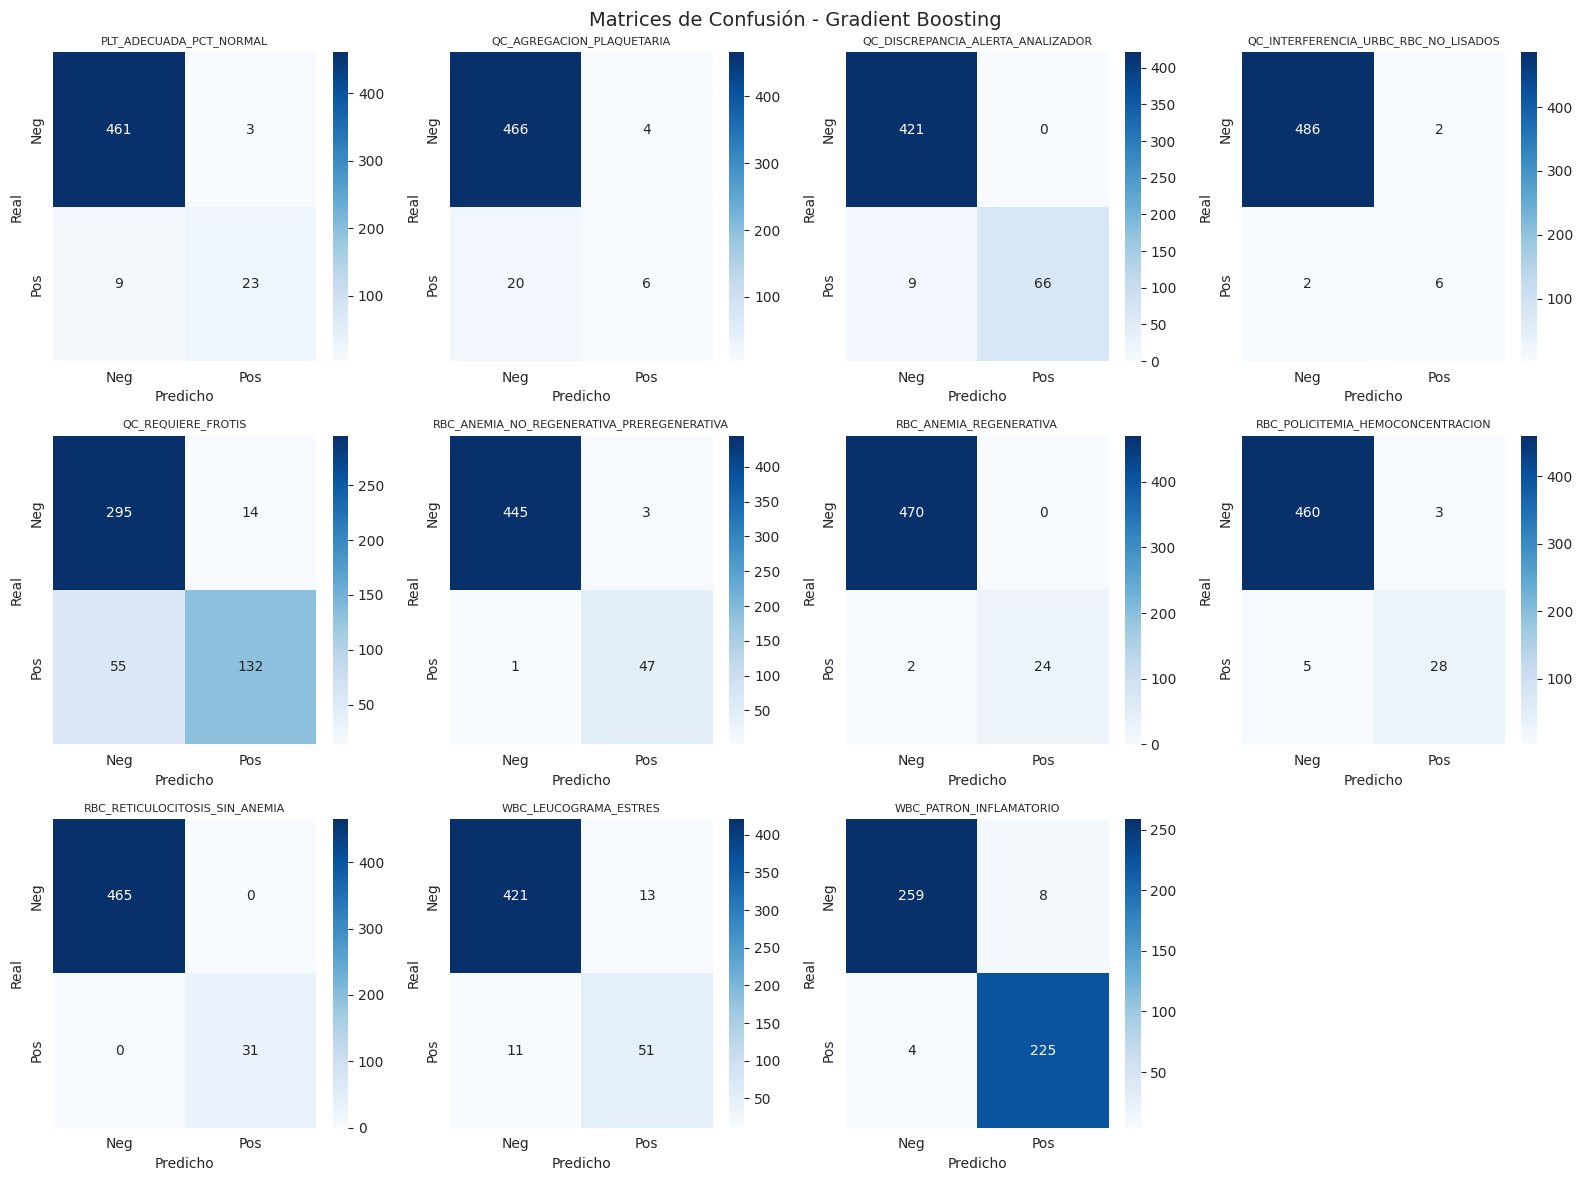

In [ ]:
# Matrices de confusión del mejor modelo
best_preds = models[best_model]

n_labels = len(target_cols)
ncols = 4
nrows = (n_labels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    label_name = col.replace("label_", "")
    cm = confusion_matrix(Y_test.iloc[:, i], best_preds[:, i])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
    axes[i].set_title(label_name, fontsize=8)
    axes[i].set_ylabel("Real")
    axes[i].set_xlabel("Predicho")

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Matrices de Confusión - {best_model}", fontsize=14)
plt.tight_layout()
plt.show()



### Luego de revisar

1. Tuning de hiperparámetros: GridSearch/RandomizedSearch para optimizar modelos.
2. Manejo de desbalance: SMOTE, class_weight, o threshold tuning para etiquetas raras.
3. Features visuales: Incorporar scatter plots WBC como features usando CNN/transfer learning.
4. Validación cruzada: Implementar k-fold CV para estimaciones más robustas.
5. Modelos avanzados: XGBoost, LightGBM, o redes neuronales multi-label.

## Siguientes Pasos

Con este baseline local establecido:
1. Procederemos al **Notebook 2b: Pipeline Final**, donde integraremos el dataset armonizado (DAP).
2. Optimizaremos los umbrales de decisión para maximizar la sensibilidad clínica.
3. Implementaremos técnicas de calibración para mejorar la fiabilidad de las predicciones.